

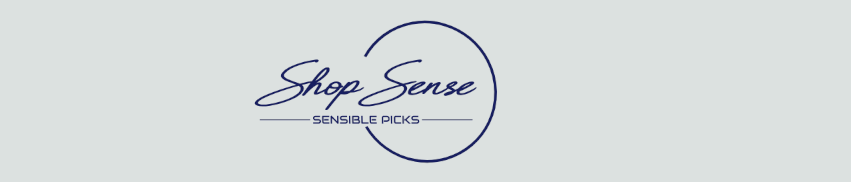

---
#**ShopSense**
#by sarvesh Pandey
---
> A Sustainable Ai Plateform "ShopSense" For Enhancing Transparency and Trust in
Consumer Goods



In [ ]:
# @title Core Installs {"display-mode":"form"}
!pip install -U langchain-google-genai gradio

In [ ]:
# @title connect drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


In [ ]:
# @title local/drive data Fetch {"display-mode":"form"}
# # 🔹 Mount Google Drive safely
# # from google.colab import drive
# # drive.mount('/content/drive', force_remount=True)

# import pandas as pd, os

# # 🔹 Prepare folder
# save_path = "/content/drive/MyDrive"
# os.makedirs(save_path, exist_ok=True)

# # 🔹 Load a smaller chunk first (10 000 rows)
# url = "https://world.openfoodfacts.org/data/en.openfoodfacts.org.products.csv"
# print(" Downloading first 10 000 rows safely…")

# df = pd.read_csv(url, sep="\t", nrows=10000, low_memory=False)

# # 🔹 Save sample to Drive
# file_path = os.path.join(save_path, "OpenFoodFacts_sample_10k.csv")
# df.to_csv(file_path, index=False)

# print(f" Saved to Google Drive: {file_path}")
# print(f" Shape: {df.shape}")


In [ ]:
#@title Imports
#imports

import IPython, langchain_google_genai, langchain_core

In [ ]:
# @title Core Model {"display-mode":"form"}
import os
os.environ['GOOGLE_API_KEY'] = 'enter your api key here';

if os.environ["GOOGLE_API_KEY"] == '':
    print({ "error": '''
        To get started, get an GOOGLE_API_KEY and enter it in the first step
    '''.replace('\n', '') })

In [ ]:
# @title Pre-Prompt For Native Output
prompt = 'Britania Good Day Biscuits'
# run for output in notebook itself

In [ ]:
# @title Dataset
import pandas as pd

# Path to the saved CSV in your Google Drive
file_path = "/content/drive/MyDrive/OpenFoodFacts_sample_10k.csv"

# Load into a dataframe
df = pd.read_csv(file_path)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
df.head()


In [ ]:
# @title ShopSense 4.5  Backend

from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO
import numpy as np

def fig_to_pil(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    plt.close(fig)
    return img

def analyze_product(prompt):
    # 1 CSV lookup
    product_data = df[df['product_name'].str.contains(prompt, case=False, na=False)]
    if not product_data.empty:
        product_summary = product_data.head(3).to_markdown()
        full_prompt = f"{prompt}\n\nProduct details from CSV:\n{product_summary}"
    else:
        full_prompt = prompt

    # 2 AI Response
    messages = [SystemMessage(content=system_instruction),
                HumanMessage(content=full_prompt)]
    buffer = []
    for chunk in model.stream(messages, stop=None):
        buffer.append(chunk.content)
    response_text = "".join(buffer)

    # 3 Extract nutrients (ensure numeric defaults)
    nutrient_values = extract_nutrients_robust(response_text)

    # 4 Nutrient vs RDA Graph
    fig1 = plt.figure(figsize=(8,5))
    nutrients = list(RDA.keys())
    product_vals = [nutrient_values.get(n,0) for n in nutrients]
    rda_vals = [RDA[n] for n in nutrients]
    colors = ['green' if product_vals[i] <= rda_vals[i] else 'red' for i in range(len(nutrients))]
    plt.bar(nutrients, product_vals, color=colors, label='Product')
    plt.bar(nutrients, rda_vals, color='gray', alpha=0.3, label='RDA')
    plt.ylabel("Amount per 100g / serving")
    plt.title(f"{prompt} Nutrient vs RDA")
    plt.legend()
    plt.tight_layout()
    fig1_img = fig_to_pil(fig1)

    # 5 Comparison Graph (fallback to blank image if none)
    comp_fig = plot_similar_products_image(prompt)
    if comp_fig:
        fig2_img = Image.open(comp_fig).convert("RGB")
    else:
        # blank image placeholder
        fig2_img = Image.new("RGB", (800,400), color=(40,40,40))

    return response_text, fig1_img, fig2_img


In [ ]:
# @title  ShopSense 4.5 — Unified Backend

import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import re
import requests
from functools import lru_cache
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI

# ------------------------------
# Load your dataset
csv_file = "/content/drive/MyDrive/OpenFoodFacts_sample_10k.csv"
df = pd.read_csv(csv_file, low_memory=False)

# ------------------------------
# AI model setup
system_instruction = """
Provide a detailed analysis report.

Include ingredients, hidden additives, nutritional analysis (energy, fat, carbs, proteins, sugars),
health outcomes, RDA values, health impact factor, preservatives/additives, and sustainability score if available. Provide sources or links if available.
"""
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

# ------------------------------
# RDA baseline (grams per 100g)
RDA = {
    "Energy": 2000,
    "Fat": 70,
    "Carbohydrates": 310,
    "Proteins": 50,
    "Sugars": 25
}

# ------------------------------
# Convert matplotlib fig to PIL image
def fig_to_pil(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    plt.close(fig)
    return img

# ------------------------------
# Extract nutrient data from AI text
def extract_nutrients_robust(text):
    nutrients = list(RDA.keys())
    values = {}
    for n in nutrients:
        match = re.search(rf'{n}.*?([0-9]+(?:\.[0-9]+)?)', text, re.IGNORECASE)
        if match:
            try:
                values[n] = float(match.group(1))
            except:
                values[n] = 0
        else:
            values[n] = 0
    return values

# ------------------------------
# Nutrient vs RDA Graph
def plot_nutrient_rda_image(nutrient_values, product_name):
    nutrients = list(RDA.keys())
    product_vals = [nutrient_values.get(n, 0) for n in nutrients]
    rda_vals = [RDA[n] for n in nutrients]

    colors = ['green' if product_vals[i] <= rda_vals[i] else 'red' for i in range(len(nutrients))]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(nutrients, product_vals, color=colors, label='Product')
    ax.bar(nutrients, rda_vals, color='gray', alpha=0.3, label='RDA')
    ax.set_ylabel("Amount per 100g / serving")
    ax.set_title(f"{product_name} Nutrient vs RDA")
    ax.legend()
    plt.tight_layout()

    return fig_to_pil(fig)

# ------------------------------
# Fetch similar products from OpenFoodFacts API
@lru_cache(maxsize=32)
def fetch_similar_products(name):
    url = f"https://world.openfoodfacts.org/cgi/search.pl?search_terms={name}&search_simple=1&action=process&json=1&page_size=5"
    try:
        return requests.get(url).json().get('products', [])
    except:
        return []

# ------------------------------
# Comparison graph for similar products
def plot_similar_products_image(product_name, nutrient_keys=['Carbohydrates', 'Fat', 'Proteins']):
    products = fetch_similar_products(product_name)
    if not products:
        return Image.new("RGB", (800, 400), color=(40, 40, 40))

    product_labels = []
    product_values = {key: [] for key in nutrient_keys}

    for p in products:
        pname = p.get('product_name', 'Unknown')
        nutriments = p.get('nutriments', {})
        valid = any(nutriments.get(k.lower(), 0) for k in nutrient_keys)
        if not valid:
            continue

        product_labels.append(pname[:15])
        for key in nutrient_keys:
            try:
                product_values[key].append(float(nutriments.get(key.lower(), 0)))
            except:
                product_values[key].append(0)

    if not product_labels:
        return Image.new("RGB", (800, 400), color=(40, 40, 40))

    x = range(len(product_labels))
    bottom = [0] * len(product_labels)
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, key in enumerate(nutrient_keys):
        vals = product_values[key]
        ax.bar(x, vals, bottom=bottom, label=key, color=colors[i])
        bottom = [bottom[j] + vals[j] for j in range(len(vals))]

    ax.set_xticks(x)
    ax.set_xticklabels(product_labels, rotation=45, ha='right')
    ax.set_ylabel("Amount per 100g")
    ax.set_title(f"Comparison of similar products: {product_name}")
    ax.legend()
    plt.tight_layout()

    return fig_to_pil(fig)

# ------------------------------
# Main analysis function (works in both native + Gradio)
def analyze_product(prompt):
    # Lookup product in CSV
    product_data = df[df['product_name'].str.contains(prompt, case=False, na=False)]
    if not product_data.empty:
        product_summary = product_data.head(3).to_markdown()
        full_prompt = f"{prompt}\n\nProduct details from CSV:\n{product_summary}"
    else:
        full_prompt = prompt

    # Generate AI text response
    messages = [SystemMessage(content=system_instruction), HumanMessage(content=full_prompt)]
    buffer = []
    for chunk in model.stream(messages, stop=None):
        buffer.append(chunk.content)
    response_text = "".join(buffer)

    # Extract nutrient info
    nutrient_values = extract_nutrients_robust(response_text)

    # Generate Graphs
    fig1_img = plot_nutrient_rda_image(nutrient_values, prompt)
    fig2_img = plot_similar_products_image(prompt)

    return response_text, fig1_img, fig2_img


In [ ]:
# @title Native response v4.5
from IPython.display import display, Markdown
response_text,fig1_img,fig2_img = analyze_product(prompt)
display(Markdown(f"### 🔹 ShopSense analysis:"))
display(Markdown(response_text))

display(Markdown("### 📊 Nutrient vs RDA Graph"))
display(fig1_img)

display(Markdown("### 📊 Comparison with Similar Products Graph"))
display(fig2_img)


In [ ]:
# @title ShopSense WebApp main Page v4.5
import gradio as gr
from PIL import Image

# Gradio wrapper function
def chat_with_ui(prompt):
    if not prompt:
        # Return placeholders if empty
        return "**⚠️ Please enter a valid product name.**", "**⚠️ Please enter a valid product name.**", Image.new("RGB",(800,400),(40,40,40)), Image.new("RGB",(800,400),(40,40,40))

    # Typing effect placeholder
    typing_effect = "**🔹ShopSense report**"

    # Call the backend
    response_text, nutrient_graph, comparison_graph = analyze_product(prompt)

    # Format response Markdown
    formatted_response = f"""
✨ ShopSense Analysis for **{prompt}**

{response_text}

---

✨ A ShopSense Sensible Request...
     Hey Hello, if you Got the analysis Report And It is  BreathTaking...
     Just Calm Down....
     Have A Seat... AND Switch To 🌱Natural Alternatives.
        Be Natural,Be Healthy.

      there is a sanskrit Shloka Says...

    चिन्तनीयाहि विपदं आदावेव प्रतिक्रिया,
    न कूप खननं युक्तं प्रदीप्ते वहनिना  गृहे|.

    |It is useless to show concern and take remedial steps only after facing a
    |disaster because then it is too late. To commence digging a well is not
    |appropriate when the house is already on fire.

     🌱 Plant Some Trees As much As You Can.
"""
    # Return: typing effect, formatted response, nutrient graph, comparison graph
    return typing_effect, formatted_response, nutrient_graph, comparison_graph

# ------------------------------
# Predefined product prompts
predefined_prompts = ["Britania Good Day Biscuits", "Parle-G Biscuits", "Maggi", "Coca Cola", "Tropicana Apple Juice"]

# ------------------------------
# Gradio UI setup
custom_css = """
/* Image Styling */
#top-image-container {
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 15px auto;  /* Adds space around image */
    width: 100%;
}
#top-image {
    display: block;
    width: 395px;  /* Change the width as needed */
    hight: 243px;
    text-align: center;
    object-fit: cover; /* Ensures the image is properly cropped */
    border-radius: 12px;  /* Rounded corners */
    border: 3px solid #0056b3;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.2);
}

body {
    background: #ffffff; /* Light mode background */
    color: #333;         /* Dark text for readability */
}
/* Login Popup */
#login-popup {
    position: fixed;
    top: 50%;
    left: 50%;
    transform: translate(-50%, -50%);
    background: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
    z-index: 999;
    text-align: center;
    border-bottom: 4px solid #0056b3; /* Blue bottom border */
}

/* Overlay Background */
#overlay {
    position: fixed;
    top: 0;
    left: 0;
    width: 100%;
    height: 100%;
    background: rgba(0, 0, 0, 0.5);
    z-index: 998;
}

/* General Styling */
body {
    background: #f8f9fa !important;
    color: #333;
    font-family: 'Arial', sans-serif;
}

/* Title */
h1 {
    text-align: center;
    color: #0056b3;
    font-size: 28px;
    font-weight: bold;
}

#profile-icon {
    position: fixed;
    top: 10px;
    right: 20px;
    font-size: 18px;
    width: 35px;
    height: 35px;
    background: white;
    color: #0056b3;
    border-radius: 50%;  /* Makes it circular */
    border: 2px solid #0056b3;
    display: flex;
    align-items: center;
    justify-content: center;
    cursor: pointer;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.1);
    transition: background 0.3s;
}

/* Instructions */
.instructions {
    background: #e3f2fd;
    padding: 15px;
    border-radius: 8px;
    margin-bottom: 20px;
}

/* Footer */
#footer {
    border-top: 3px solid #0056b3;
    padding: 10px;
    text-align: center;
    font-weight: bold;
    height: 50px;
    background: #f0f4f8;
    color: #333;
    position: fixed;
    bottom: 0;
    left: 0;
    width: 100%;
    box-shadow: 0px -2px 5px rgba(0, 0, 0, 0.1);
}

/* Demo Menus */
#menu {
    margin-top: 20px;
    text-align: center;
    font-size: 14px;
}
#menu a {
    color: #0056b3;
    margin: 0 10px;
    text-decoration: none;
    font-weight: bold;
}

/* Input & Buttons */
.gr-textbox {
    background: #ffffff !important;
    color: #333 !important;
    border-radius: 10px !important;
    border: 2px solid #0056b3 !important;
    padding: 12px;
    font-size: 16px;
}

.gr-button-primary {
    background: #0056b3 !important;
    color: white !important;
    border-radius: 8px !important;
    padding: 10px 20px;
    font-size: 16px;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.1);
}

.gr-dropdown {
    background: #ffffff !important;
    color: #333 !important;
    border-radius: 10px !important;
    border: 1px solid #0056b3;
    padding: 8px;
}

/* Align Buttons */
.icon-button {
    font-size: 18px;
    padding: 5px;
    min-width: 40px;

}
"""

# ------------------------------
# Create Gradio app
with gr.Blocks(css=custom_css) as demo:
    gr.Markdown("<h1> 💡 ShopSense✨</h1>", elem_id="title")

    with gr.Row():
        with gr.Column(scale=3):
            gr.Markdown("### 💡 Here are Instructions")
            gr.Markdown("1. **Enter a product name** or select one from the dropdown.")
            gr.Markdown("2. Click the **Analyze With ShopSense** button to generate 🔹ShopSense insights.")
            gr.Markdown("3. View the **detailed Analysis report** below.")

        with gr.Column(scale=4):
            with gr.Row():
                prompt_input = gr.Textbox(label="🔹 Enter Product Name", placeholder="Type a product name...", lines=1)
                camera_btn = gr.Button("📷", elem_id="camera-button")
                clipboard_btn = gr.Button("📋", elem_id="clipboard-button")

            dropdown = gr.Dropdown(predefined_prompts, label="🔹 Or Select a Product", interactive=True)
            submit_btn = gr.Button(" ✨ Analyse With ShopSense", variant="primary")

    gr.Markdown("### 📝 ShopSense Insights", elem_id="subtitle")
    loading_text = gr.Markdown("", elem_id="loading-text")
    response_output = gr.Markdown("**✨ShopSense analysis will appear here.**", elem_id="output-box")
    nutrient_graph = gr.Image(label="Nutrient vs RDA", type="pil")
    comparison_graph = gr.Image(label="Comparison with Similar Products", type="pil")

    # ------------------------------
    # Link buttons to backend
    submit_btn.click(chat_with_ui,
                     inputs=[prompt_input],
                     outputs=[loading_text, response_output, nutrient_graph, comparison_graph])

    dropdown.change(chat_with_ui,
                    inputs=[dropdown],
                    outputs=[loading_text, response_output, nutrient_graph, comparison_graph])

    dropdown.change(lambda x: x,
                    inputs=[dropdown],
                    outputs=[prompt_input])

    gr.Markdown("<div id='footer'>🌟 Built </div>")

demo.launch(share=True)


In [ ]:
# @title ✨Launch ShopSense WebApp v4.5
import gradio as gr
from PIL import Image

# Gradio wrapper function
def chat_with_ui(prompt):
    if not prompt:
        # Return placeholders if empty
        return "**⚠️ Please enter a valid product name.**", "**⚠️ Please enter a valid product name.**", Image.new("RGB",(800,400),(40,40,40)), Image.new("RGB",(800,400),(40,40,40))

    # Typing effect placeholder
    typing_effect = "**🔹ShopSense report**"

    # Call the backend
    response_text, nutrient_graph, comparison_graph = analyze_product(prompt)

    # Format response Markdown
    formatted_response = f"""
✨ ShopSense Analysis for **{prompt}**

{response_text}

---

✨ A ShopSense Sensible Request...
     Hey Hello, if you Got the analysis Report And It is  BreathTaking...
     Just Calm Down....
     Have A Seat... AND Switch To 🌱Natural Alternatives.
        Be Natural,Be Healthy.

      there is a sanskrit Shloka Says...

    चिन्तनीयाहि विपदं आदावेव प्रतिक्रिया,
    न कूप खननं युक्तं प्रदीप्ते वहनिना  गृहे|.

    |It is useless to show concern and take remedial steps only after facing a
    |disaster because then it is too late. To commence digging a well is not
    |appropriate when the house is already on fire.

     🌱 Plant Some Trees As much As You Can.
"""
    # Return: typing effect, formatted response, nutrient graph, comparison graph
    return typing_effect, formatted_response, nutrient_graph, comparison_graph

# ------------------------------
# Predefined product prompts
predefined_prompts = ["Britania Good Day Biscuits", "Parle-G Biscuits", "Maggi", "Coca Cola", "Tropicana Apple Juice"]

# ------------------------------
# Gradio UI setup
custom_css = """
/* Image Styling */
#top-image-container {
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 15px auto;  /* Adds space around image */
    width: 100%;
}
#top-image {
    display: block;
    width: 395px;  /* Change the width as needed */
    hight: 243px;
    text-align: center;
    object-fit: cover; /* Ensures the image is properly cropped */
    border-radius: 12px;  /* Rounded corners */
    border: 3px solid #0056b3;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.2);
}

body {
    background: #ffffff; /* Light mode background */
    color: #333;         /* Dark text for readability */
}
/* Login Popup */
#login-popup {
    position: fixed;
    top: 50%;
    left: 50%;
    transform: translate(-50%, -50%);
    background: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.2);
    z-index: 999;
    text-align: center;
    border-bottom: 4px solid #0056b3; /* Blue bottom border */
}

/* Overlay Background */
#overlay {
    position: fixed;
    top: 0;
    left: 0;
    width: 100%;
    height: 100%;
    background: rgba(0, 0, 0, 0.5);
    z-index: 998;
}

/* General Styling */
body {
    background: #f8f9fa !important;
    color: #333;
    font-family: 'Arial', sans-serif;
}

/* Title */
h1 {
    text-align: center;
    color: #0056b3;
    font-size: 28px;
    font-weight: bold;
}

#profile-icon {
    position: fixed;
    top: 10px;
    right: 20px;
    font-size: 18px;
    width: 35px;
    height: 35px;
    background: white;
    color: #0056b3;
    border-radius: 50%;  /* Makes it circular */
    border: 2px solid #0056b3;
    display: flex;
    align-items: center;
    justify-content: center;
    cursor: pointer;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.1);
    transition: background 0.3s;
}

/* Instructions */
.instructions {
    background: #e3f2fd;
    padding: 15px;
    border-radius: 8px;
    margin-bottom: 20px;
}

/* Footer */
#footer {
    border-top: 3px solid #0056b3;
    padding: 10px;
    text-align: center;
    font-weight: bold;
    height: 46px;
    background: #f0f4f8;
    color: #333;
    position: fixed;
    bottom: 0;
    left: 0;
    width: 100%;
    box-shadow: 0px -2px 5px rgba(0, 0, 0, 0.1);
}
footer {display: none !important;}
share-btn-container {display: none !important;}
/* Demo Menus */
#menu {
    margin-top: 20px;
    text-align: center;
    font-size: 14px;
}
#menu a {
    color: #0056b3;
    margin: 0 10px;
    text-decoration: none;
    font-weight: bold;
}

/* Input & Buttons */
.gr-textbox {
    background: #ffffff !important;
    color: #333 !important;
    border-radius: 10px !important;
    border: 2px solid #0056b3 !important;
    padding: 12px;
    font-size: 16px;
}

.gr-button-primary {
    background: #0056b3 !important;
    color: white !important;
    border-radius: 8px !important;
    padding: 10px 20px;
    font-size: 16px;
    box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.1);
}

.gr-dropdown {
    background: #ffffff !important;
    color: #333 !important;
    border-radius: 10px !important;
    border: 1px solid #0056b3;
    padding: 8px;
}

/* Align Buttons */
.icon-button {
    font-size: 18px;
    padding: 5px;
    min-width: 40px;

}
#loading-text {
    font-size:15px;
    font-style:italic;
    color:#00A8E8;
    margin-bottom:10px;
    animation: pulse 1.5s infinite;
}
@keyframes pulse {
    0% {opacity: 0.3;}
    50% {opacity: 1;}
    100% {opacity: 0.3;}
}

/* Scrollable output section */
 #scrollable-output {

     max-height: 1900px;
     overflow-y: auto;
     border: 2px solid #0056b3;
     border-radius: 10px;
     padding: 10px;
     background: #ffffff;
     margin-bottom: 10px;
}

/* 🔹 Floating toast popup */
#toast {
  position: fixed;
  top: 25px;
  right: 25px;
  background-color: #0056b3;
  color: white;
  padding: 12px 18px;
  border-radius: 10px;
  box-shadow: 0 0 12px rgba(0, 168, 232, 0.5);
  font-weight: 500;
  font-size: 15px;
  display: none;
  z-index: 9999;
  opacity: 0;
  transition: opacity 0.5s ease-in-out;
}


"""

# ------------------------------
# Create the ui
with gr.Blocks(css=custom_css) as demo:
    toast_html = gr.HTML("<div id='toast'></div>")  # popup placeholder


    # Login Popup
    with gr.Row(visible=True, elem_id="overlay") as overlay:
        with gr.Column(elem_id="login-popup"):
            gr.Markdown("### 🔐 Login Required")
            username_input = gr.Textbox(label="👤 Username")
            password_input = gr.Textbox(label="🔒 Password", type="password")
            login_button = gr.Button("Login")
            login_status = gr.Markdown("", visible=False)
            gr.HTML("<div style='color: #0056b3; margin-top: 10px;'> ✨ShopSense</div>")

             # New Variable to Store Logged-in Username
            logged_in_user = gr.State("")

    # Main App UI (Initially Hidden)
    with gr.Column(visible=False, elem_id="app-content") as app_content:
        gr.HTML("""
           <div id="top-image-container">
           <img id="top-image" src="https://lh3.googleusercontent.com/d/1eZhO85lrSyY7FC8l4tmNgmKFSxdpc0ls=w395-h243" alt="Top Image">
           </div>
           """)
        # Profile Icon at the Top-Right Corner
        profile_icon = gr.Button("👤", elem_id="profile-icon")

        # Display Username when Profile Icon is Clicked
        user_display = gr.Markdown("👤 User: Guest", visible=False)
        gr.Markdown("<h1> 💡ShopSense ✨</h1>", elem_id="title")

         # Instructions Section
        with gr.Row(elem_classes=["instructions"]):
            gr.Markdown("""
            ### 📝 Here are Instructions:
            1. **Enter a product name** or select one from the dropdown.
            2. Click **Analyze With ShopSense** to generate insights.
            3. View the **detailed Analysis report** below.
            """)

        with gr.Row():
            prompt_input = gr.Textbox(label="🔹 Enter Product Name...", placeholder="Type a product name...", lines=1)
            with gr.Column(scale=0.2):  # Smaller Icons
                camera_btn = gr.Button("📷 Take Picture", elem_id="camera-button", elem_classes=["icon-button"])
                clipboard_btn = gr.Button("📋 Select Local File", elem_id="clipboard-button", elem_classes=["icon-button"])
                voice_btn = gr.Button("🎙️ Ask Me", elem_id="voice-button", elem_classes=["icon-button"])

        dropdown = gr.Dropdown(predefined_prompts, label="🔹 Or Select a Product", interactive=True)
        submit_btn = gr.Button(" ✨ Analyse With ShopSense",variant="primary")

        gr.Markdown("### 📝 ShopSense Insights", elem_id="subtitle")
        loading_text = gr.Markdown("", elem_id="loading-text")

        with gr.Column(elem_id="scrollable-output"):
            response_output = gr.Markdown("**✨ShopSense analysis will appear here.**", elem_id="output-box")
            nutrient_graph = gr.Image(label="Nutrient vs RDA", type="pil",height=400)
            comparison_graph = gr.Image(label="Comparison with Similar Products", type="pil", height=400)

        # Demo Menus
        gr.HTML("""
        <div id='menu'>
            <a href='#'>About Us</a>
            <a href='#'>Contact Us</a> |
            <a href='#'>Privacy Policy</a> |
            <a href='#'>Terms of Service</a>
        </div>
        """)

    # Login Functionality
    def validate_login(username, password):
        if username == "admin" and password == "1234":
            return (
                gr.update(visible=False),  # Hide login popup
                gr.update(visible=True),   # Show main app UI
                "**✅ Login Successful! Welcome, " + username + "!**",
                username  # Store Logged-in Username

            )
        else:
            return (
                gr.update(visible=True),
                gr.update(visible=False),
                "** Invalid Credentials. Try Again!**",
                ""  # Clear Username on Failed Login
            )
    def show_username(user):
      return gr.update(value=f"👤 User: {user}", visible=True) if user else gr.update(visible=False)
    # Login Button Click
    login_button.click(validate_login, inputs=[username_input, password_input], outputs=[overlay, app_content, login_status, logged_in_user])
   # Profile Icon Click to Show Username
    profile_icon.click(show_username, inputs=[logged_in_user], outputs=[user_display])

    toast_static = """
    () => {
      const toast = document.getElementById('toast');
      if (!toast) return;
      toast.textContent = ' This feature is under development.';
      toast.style.display = 'block';
      setTimeout(() => { toast.style.opacity = 1; }, 50);
      setTimeout(() => { toast.style.opacity = 0; }, 1800);
      setTimeout(() => { toast.style.display = 'none'; }, 2300);
    }
    """
    camera_btn.click(None,js=toast_static)
    clipboard_btn.click(None,js=toast_static)
    voice_btn.click(None,js=toast_static)







    # ------------------------------
    # Link buttons to backend
    submit_btn.click(chat_with_ui, inputs=[prompt_input], outputs=[loading_text, response_output, nutrient_graph, comparison_graph])

    dropdown.change(chat_with_ui, inputs=[dropdown], outputs=[loading_text, response_output, nutrient_graph, comparison_graph])

    dropdown.change(lambda x: x, inputs=[dropdown], outputs=[prompt_input])

    gr.Markdown("<div id='footer'>🌟 Built with💖by Sarvesh Pandey  </div>")



# demo.launch(share=True)
# Launch Gradio app
demo.launch(share=True,

          #  favicon_path="favicon.ico",
           # title="AI WebApp",
            #allow_flagging="never"
            )


================================================================================